## Link to project github repo: https://github.com/muxinfu-dev/data1030project.git
## project question: Predict an individual’s actual_productivity_score

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, KFold
from scipy import sparse
df = pd.read_csv("/Users/fumuxin/Desktop/data1030-fall2025/social_media_vs_productivity.csv")
print(df.shape)
print(df.info())
print(df.isna().mean())
print(df.duplicated().sum())
df['stress_level'].value_counts()


(30000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work  

stress_level
3.0     2857
10.0    2852
5.0     2846
6.0     2834
4.0     2818
9.0     2807
7.0     2796
8.0     2777
2.0     2766
1.0     2743
Name: count, dtype: int64

**Intro Slides**
1. explain the problem you want to solve

   - Predict an individual’s actual_productivity_score from their digital-behavior and routine features (e.g., daily social-media time, notifications, screen-time before sleep, breaks, sleep hours), in order to quantify how specific habits relate to real productivity.

2. why this is important

   - Organizations and students care about doing more without burning out; evidence-based guidance on notifications, breaks, and focus tools can improve output and well-being.
   - Results can inform digital-wellbeing policies, app features (e.g., batching notifications), and personal habit recommendations, with transparent model explanations (feature importances/SHAP).

     
3. whether it is a regression or classification problem

   Its a regression problem.

   
4. where you got the data from, how the data was collected

   - Data source: [https://www.kaggle.com/datasets/mahdimashayekhi/social-media-vs-productivity]
   - how it was collected: it’s a synthetic / simulated dataset designed to mirror plausible relationships among digital habits and outcomes.
     
     
5. which of the three difficulties it contains (missing data, large data, or non-iid)

 - Missing data 


## EDA Graphs

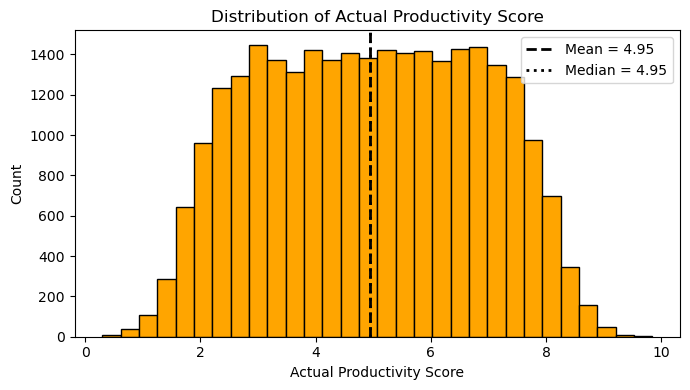

In [2]:
plt.figure(figsize=(7,4))
series = df['actual_productivity_score'].dropna()
plt.hist(series, bins=30, color='orange', edgecolor='black')
plt.axvline(series.mean(), color='black', linestyle='--', linewidth=2, label=f"Mean = {series.mean():.2f}")
plt.axvline(series.median(), color='black', linestyle=':', linewidth=2, label=f"Median = {series.median():.2f}")
plt.title("Distribution of Actual Productivity Score")
plt.xlabel("Actual Productivity Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


1. why choose
   - I chose this figure to provide an overall view of how productivity is distributed in the dataset.
     
2. Why interesting, unexpected, important?
   - The roughly symmetric bell-shaped curve centered around 5 indicates that most respondents fall in the mid-productivity range. This distribution also helps check for skewness or outliers that could bias later modeling. In this case, the distribution appears fairly balanced with no strong skew and no extreme outliers, which suggests that standard modeling techniques can be applied without major transformations.

/var/folders/jh/p7pfnk2525v6hf5n3nvd8zfr0000gn/T/ipykernel_34747/177724540.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = df2.pivot_table(index='job_type', columns='sm_time_bin', values='actual_productivity_score', aggfunc='mean')


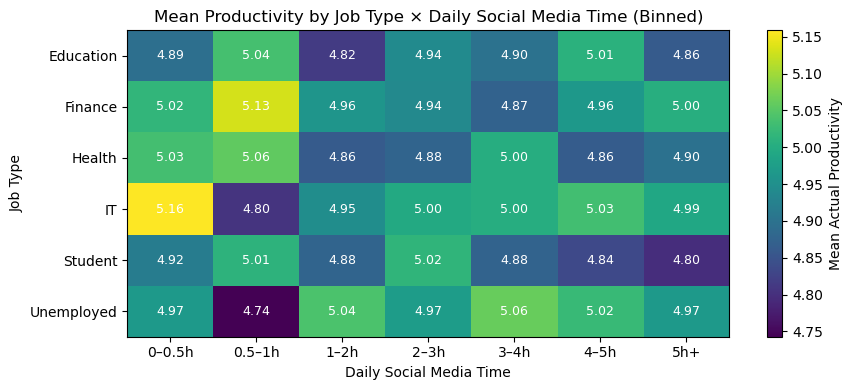

In [26]:
bins = [0, 0.5, 1, 2, 3, 4, 5, np.inf]
labels = ["0–0.5h","0.5–1h","1–2h","2–3h","3–4h","4–5h","5h+"]
df2 = df[['job_type','daily_social_media_time','actual_productivity_score']].dropna(subset=['job_type','daily_social_media_time','actual_productivity_score']).copy()
df2['sm_time_bin'] = pd.cut(df2['daily_social_media_time'], bins=bins, labels=labels, right=False, include_lowest=True)

pivot_mean = df2.pivot_table(index='job_type', columns='sm_time_bin', values='actual_productivity_score', aggfunc='mean')

plt.figure(figsize=(9, max(4, 0.35*len(pivot_mean.index))))
im = plt.imshow(pivot_mean.values, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Mean Actual Productivity")
plt.xticks(ticks=np.arange(len(pivot_mean.columns)), labels=list(pivot_mean.columns))
plt.yticks(ticks=np.arange(len(pivot_mean.index)), labels=list(pivot_mean.index))
plt.title("Mean Productivity by Job Type × Daily Social Media Time (Binned)")
plt.xlabel("Daily Social Media Time")
plt.ylabel("Job Type")
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        value = pivot_mean.values[i, j]
        if not np.isnan(value):
            plt.text(
                j, i, f"{value:.2f}", 
                ha='center', va='center', color='white', fontsize=9
            )

plt.tight_layout()
plt.show()

1. why choose

   - This figure was selected because it reveals interaction effects between job type and social media habits—something that wouldn’t be visible from summary statistics alone. Interestingly, IT and Finance exhibit more pronounced variation in productivity across different levels of social media use, while some other job types remain more stable. This indicates that the relationship between social media usage and productivity is highly context-dependent, likely influenced by the nature of the work and its sensitivity to distraction.
   
3. Why interesting, unexpected, important?

   -  Interestingly, IT and Finance exhibit more pronounced variation in productivity across different levels of social media use, while some other job types remain more stable. This indicates that the relationship between social media usage and productivity is highly context-dependent, likely influenced by the nature of the work and its sensitivity to distraction.

/var/folders/jh/p7pfnk2525v6hf5n3nvd8zfr0000gn/T/ipykernel_14287/2552818044.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (d.groupby(['cups_int','age_group'])[y]
/var/folders/jh/p7pfnk2525v6hf5n3nvd8zfr0000gn/T/ipykernel_14287/2552818044.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, sub in g.groupby('age_group'):


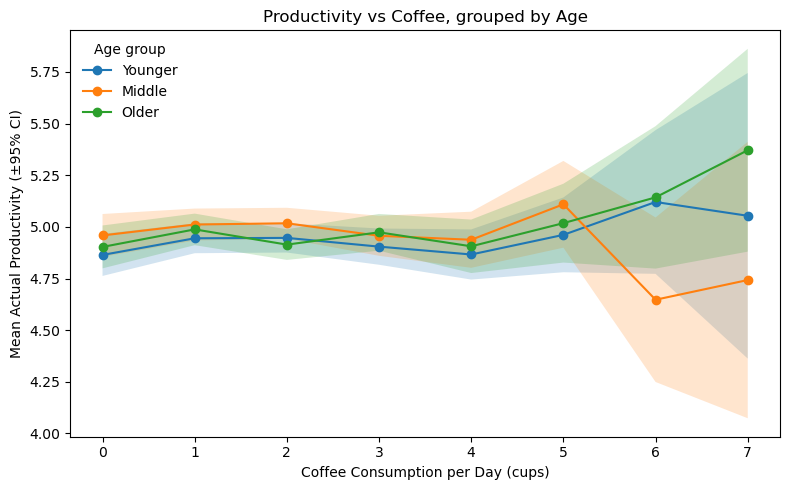

In [4]:

cups = 'coffee_consumption_per_day'
y    = 'actual_productivity_score'
age  = 'age'

d = df[[cups, y, age]].dropna().copy()

d['cups_int'] = np.clip(np.rint(d[cups]).astype(int), 0, 10)

d['age_group'] = pd.qcut(d[age], 3, labels=['Younger','Middle','Older'])

g = (d.groupby(['cups_int','age_group'])[y]
       .agg(mean='mean', std='std', count='size')
       .reset_index())
g['sem']  = g['std'] / np.sqrt(g['count'].clip(lower=1))
g['ci95'] = 1.96 * g['sem']

min_n = 15
g = g[g['count'] >= min_n]

fig, ax = plt.subplots(figsize=(8,5))
for label, sub in g.groupby('age_group'):
    sub = sub.sort_values('cups_int')
    ax.plot(sub['cups_int'], sub['mean'], marker='o', label=label)
    ax.fill_between(sub['cups_int'], sub['mean']-sub['ci95'], sub['mean']+sub['ci95'], alpha=0.2)

ax.set_xlabel('Coffee Consumption per Day (cups)')
ax.set_xticks(range(int(g['cups_int'].min()), int(g['cups_int'].max())+1))
ax.set_ylabel('Mean Actual Productivity (±95% CI)')
ax.set_title('Productivity vs Coffee, grouped by Age')
ax.legend(title='Age group', frameon=False)
plt.tight_layout()
plt.show()


1. why choose

   - It reveals how coffee consumption affects productivity differently across age groups, highlighting interaction effects that simple averages would miss.
   
3. Why interesting, unexpected, important?

   The diverging trends at higher consumption levels are particularly interesting: older participants show a steady increase in productivity with more coffee, whereas middle-aged participants experience a drop and younger participants level off. This pattern is unexpected and suggests potential behavioral or physiological differences between groups.

**Splitting**

In [9]:
target_col = 'actual_productivity_score'                   
work = df.dropna(subset=[target_col]).copy()              
X, y = work.drop(columns=[target_col]), work[target_col]  

#hold out 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. K-Fold splitting only on training set
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    X_train_fold = X_train.iloc[train_idx]
    X_val_fold   = X_train.iloc[val_idx]
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold   = y_train.iloc[val_idx]
    print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")



Fold 1: train=17686, val=4422
Fold 2: train=17686, val=4422
Fold 3: train=17686, val=4422
Fold 4: train=17687, val=4421
Fold 5: train=17687, val=4421

Train size: 22108, Test size: 5527


**Randomness of Missing Values Test**

In [11]:
print("=== Missingness Randomness Check with statsmodels Logit (TRAIN ONLY) ===")

X_train_base = X_train.copy()

# list features that have any missingness on train set
missing_features = [col for col in X_train_base.columns if X_train_base[col].isna().any()]

for feat in missing_features:
    # binary target: 1 if the feature is missing on this row, else 0
    miss_flag = X_train_base[feat].isna().astype(int)
    if miss_flag.mean() == 0 or miss_flag.mean() == 1:
        continue

    # predictors exclude the feature whose missingness we are modeling
    X_pred = X_train_base.drop(columns=[feat]).copy()

    # Treat booleans as numeric 0/1
    bool_cols_pred = X_pred.select_dtypes(include=["bool"]).columns.tolist()
    if bool_cols_pred:
        X_pred[bool_cols_pred] = X_pred[bool_cols_pred].astype(int)

    # Define column types
    num_cols_pred  = X_pred.select_dtypes(include=["number"]).columns.tolist()
    cat_cols_pred  = X_pred.select_dtypes(include=["object", "category"]).columns.tolist()

    num_pipe = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler())
    cat_pipe = make_pipeline(SimpleImputer(strategy="most_frequent"),
                             OneHotEncoder(handle_unknown="ignore", sparse_output=False))

    preproc = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols_pred),
            ("cat", cat_pipe, cat_cols_pred),
        ],
        remainder="drop"
    )


    X_design = preproc.fit_transform(X_pred)


    feat_names = preproc.get_feature_names_out()
    X_df = pd.DataFrame(X_design, columns=feat_names, index=X_pred.index)

    # Add intercept
    X_df = sm.add_constant(X_df, has_constant="add")

    try:
        model = sm.Logit(miss_flag, X_df).fit(disp=False, maxiter=200)
        pr2 = 1.0 - (model.llf / model.llnull)

        print(f"\nFeature: {feat}")
        print(f"  Missing rate: {miss_flag.mean():.3f}")
        print(f"  McFadden R^2: {pr2:.3f}")

        if pr2 < 0.02:
            print("  Interpretation: Weak predictability-->consistent with MCAR.")
        elif pr2 < 0.13:
            print("  Interpretation: Moderate predictability-->likely MAR.")
        else:
            print("  Interpretation: Strong predictability-->likely MAR/MNAR.")

    except Exception as e:
        print(f"\nFeature: {feat} — Logit failed: {e}")


=== Missingness Randomness Check with statsmodels Logit (TRAIN ONLY) ===

Feature: daily_social_media_time
  Missing rate: 0.091
  McFadden R^2: 0.001
  Interpretation: Weak predictability-->consistent with MCAR.

Feature: perceived_productivity_score
  Missing rate: 0.054
  McFadden R^2: 0.002
  Interpretation: Weak predictability-->consistent with MCAR.

Feature: stress_level
  Missing rate: 0.064
  McFadden R^2: 0.004
  Interpretation: Weak predictability-->consistent with MCAR.

Feature: sleep_hours
  Missing rate: 0.086
  McFadden R^2: 0.002
  Interpretation: Weak predictability-->consistent with MCAR.

Feature: screen_time_before_sleep
  Missing rate: 0.075
  McFadden R^2: 0.002
  Interpretation: Weak predictability-->consistent with MCAR.

Feature: job_satisfaction_score
  Missing rate: 0.089
  McFadden R^2: 0.001
  Interpretation: Weak predictability-->consistent with MCAR.


**Preprocessing**

In [25]:
# ===== 2) Preprocessing (fit on TRAIN only; transform TRAIN & TEST) =====

# Age binning: learn cut points on TRAIN only
age_labels = ['Younger','Middle','Older']
age_edges = None

age_q = pd.qcut(X_train['age'], q=3, duplicates='drop')
lefts  = [iv.left  for iv in age_q.cat.categories]
rights = [iv.right for iv in age_q.cat.categories]
age_edges = np.unique(np.concatenate(([lefts[0]], rights)))

def add_age_group(df):
    out = df.copy()
    if (age_edges is not None) and ('age' in out.columns):
        out['age_group'] = pd.cut(
            out['age'], bins=age_edges, include_lowest=True, labels=age_labels
        )
    return out

X_train_aug = add_age_group(X_train)
X_test_aug  = add_age_group(X_test)

# Column groups
num_cols  = X_train_aug.select_dtypes(include=['number']).columns.tolist()
cat_cols  = X_train_aug.select_dtypes(include=['object','category']).columns.tolist()
bool_cols = X_train_aug.select_dtypes(include=['bool']).columns.tolist()

# Use age_group instead of raw age
if 'age' in num_cols:
    num_cols.remove('age')
    if 'age_group' not in cat_cols:
        cat_cols.append('age_group')

for c in bool_cols:
    if c in num_cols: num_cols.remove(c)
    if c in cat_cols: cat_cols.remove(c)


# Pipelines
num_pipe = make_pipeline(SimpleImputer(strategy="mean"), StandardScaler())
cat_pipe = make_pipeline(SimpleImputer(strategy="most_frequent"),
                         OneHotEncoder(handle_unknown="ignore"))

preprocessor = ColumnTransformer(transformers=[("num", num_pipe, num_cols),("cat", cat_pipe, cat_cols),("bool", "passthrough", bool_cols),],remainder="drop")
# Fit on TRAIN only; transform TRAIN & TEST
preprocessor.fit(X_train_aug)
X_train_proc = preprocessor.transform(X_train_aug)
X_test_proc  = preprocessor.transform(X_test_aug)
feat_names   = preprocessor.get_feature_names_out()

# ===== Missingness report (before preprocessing) =====
row_missing_frac = X.isna().any(axis=1).mean()
per_feature_missing = X.isna().mean().sort_values(ascending=False)
n_features_total = X.shape[1]
n_features_with_missing = int((per_feature_missing > 0).sum())
frac_features_with_missing = (n_features_with_missing / n_features_total) if n_features_total else 0.0

print("==== Shapes (data points & features) ====")
print(f"Original (after dropping missing target): X: {X.shape}, y: {y.shape}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features BEFORE preprocessing: {n_features_total}")
print(f"Features AFTER preprocessing: {len(feat_names)}")
print("\n==== Missingness Summary (before preprocessing) ====")
print(f"Fraction of rows with ANY missing feature: {row_missing_frac:.3f}")
print(f"Number of features with any missing: {n_features_with_missing}/{n_features_total} "
      f"({frac_features_with_missing:.2%})")
print("Top features by missingness (up to 10):")
print(per_feature_missing.head(10).to_string())
print()

# ===== Sanity check after preprocessing =====
print("==== Sanity check after preprocessing ====")
print("Train matrix type/shape:", type(X_train_proc), getattr(X_train_proc, "shape", None))
print("Test  matrix type/shape:", type(X_test_proc),  getattr(X_test_proc,  "shape", None))

def check_nan(Xm, name):
    if sparse.issparse(Xm):
        sample = Xm[:200].toarray()
        has_nan = np.isnan(sample).any()
    else:
        has_nan = np.isnan(Xm).any()
    print(f"{name} contains NaN after preprocessing? {bool(has_nan)}")

check_nan(X_train_proc, "TRAIN")
check_nan(X_test_proc,  "TEST")

==== Shapes (data points & features) ====
Original (after dropping missing target): X: (27635, 18), y: (27635,)
Train: (22108, 18) | Test: (5527, 18)
Features BEFORE preprocessing: 18
Features AFTER preprocessing: 31

==== Missingness Summary (before preprocessing) ====
Fraction of rows with ANY missing feature: 0.382
Number of features with any missing: 6/18 (33.33%)
Top features by missingness (up to 10):
daily_social_media_time         0.091912
job_satisfaction_score          0.090429
sleep_hours                     0.087498
screen_time_before_sleep        0.073892
stress_level                    0.063506
perceived_productivity_score    0.053736
job_type                        0.000000
social_platform_preference      0.000000
number_of_notifications         0.000000
work_hours_per_day              0.000000

==== Sanity check after preprocessing ====
Train matrix type/shape: <class 'numpy.ndarray'> (22108, 31)
Test  matrix type/shape: <class 'numpy.ndarray'> (5527, 31)
TRAIN contains

**Report of Splitting & Preprocessing**


1. Data Splitting:

   
   - I first removed rows with missing target values to ensure the target variable would not introduce bias during training. Then, I split the dataset into training (80%) and test (20%) sets before any imputation or scaling to prevent data leakage. I also set up a 5-fold split on the training set to enable future model selection or hyperparameter tuning if needed. All preprocessing steps will be learned exclusively from the training data and then applied consistently to the test set.
   
2. Preprocessing:(speficy why categorize)

   - Numeric: Applied SimpleImputer(strategy="mean") to fill missing numeric values, followed by StandardScaler to standardize features.
   - Categorical & Booleans: For categorical variables, applied SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore"). Boolean variables were passed through without scaling or encoding to retain their original 0/1 form.
   - Binning: On the training set, I binned age into ['Younger', 'Middle', 'Older'] using quantile cut points learned on train and applied the same edges to the test set. This improves interpretability by grouping ages into meaningful categories without imposing a linear structure.
   - Before preprocessing, data shape is (27635,18)
   - After splitting, the training set has 22108 samples and the test set has 5527 samples.
   - After preprocessing(using ohe), the feature count increased to 31.

3. Missing Values:

   - MCAR check (train only): For each feature with missingness, I modeled a missingness indicator using a logistic regression (Logit) model over the remaining features. The resulting $R^2$ values were close to zero, indicating weak predictability of missingness and supporting the MCAR assumption, which justifies using simple imputation.
   - Row-level missingness: 38.2% of data points had at least one missing feature.
   - Features with missingness: 6 out of 18 features (33.3%) contained missing values.
   - The top features with missingness were: daily_social_media_time 9.19%, job_satisfaction_score 9.04%, sleep_hours 8.75%, screen_time_before_sleep 7.39%, stress_level 6.35%, perceived_productivity_score 5.37%.
   - After preprocessing, there were no missing values remaining in any split, confirming successful imputation.